$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.2

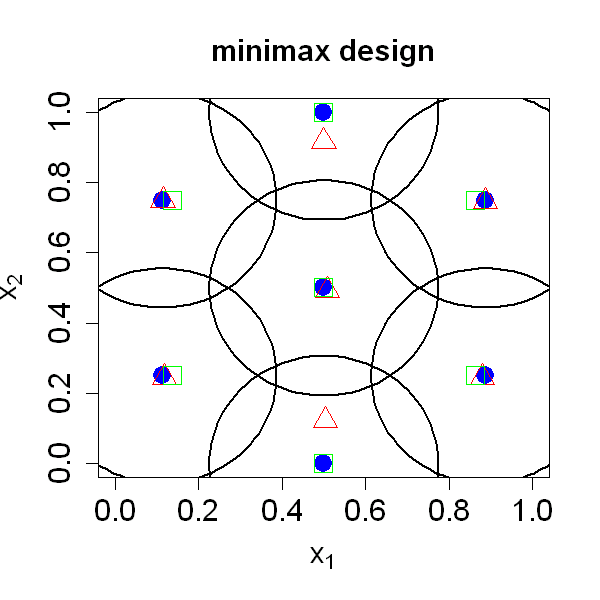

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 背景信息

一般而言,当 $p\ge2$ 时求解极小极大设计难度很高(但远小于求解最小均方误差设计).图 4.2 展示了 $n=7$ ,$p=2$ 对应的极小极大设计.对比图 4.1 中基于聚类的设计,该设计的样本点更靠近区域边界.图中还以各设计点为球心绘制了半径为 $\varphi(D)$(即填充距离)的球体,可见这些球体能够完整覆盖整个试验区域 $\mathcal{X}$.马克与约瑟夫提出基于聚类的极小极大设计生成方法.首先从试验区域 $\mathcal{X}$ 中抽取大规模均匀样本 $\{\boldsymbol{X}_{j}\}_{j=1}^{N}$ ;当 $q$ 充分大时,满足 $$\begin{align*}\left(\frac{1}{N}\sum_{j=1}^{N}\sum_{i=1}^{n}\delta_{ij}\|\boldsymbol{X}_{j}-\boldsymbol{x}_{i}\|^{q}\right)^{1/q}&\approx\max_{i=1:n}\max_{j=1:N}\delta_{ij}\|\boldsymbol{X}_{j}-\boldsymbol{x}_{i}\|\\&=\max_{i=1:n}\max_{\boldsymbol{X}_{j}\in V_{i}}\|\boldsymbol{X}_{j}-\boldsymbol{x}_{i}\|,\end{align*}$$ 其中若 $\boldsymbol{X}_{j}\in V_{i}$ 则 $\delta_{ij}=1$ ,否则 $\delta_{ij}=0$ .该式说明,只需将 $q$ 取足够大的值(但不宜过大以避免数值失稳),即可采用劳埃德 k 均值类算法求解极小极大设计.由于劳埃德算法通常仅收敛至局部最优解,作者进一步引入粒子群优化算法对设计进行优化.该算法的实现代码收录于 R 语言程序包 `minimaxdesign`(马克,2021).何(2017a)提出一类基于特殊格点设计的高效极小极大设计构造方法,但该方法仅适用于维度 $p$ 较小的场景,相关工具可参见 R 语言程序包 `LatticeDesign`.

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 指令

创建画布宽,高均为 5 英寸.对于 `2` 维平面,`7` 个点的极小极大设计,可先从几何角度求解精确值.已知 $(0,0)$ 点是坏点,由此出发即可求解蜂窝状的极小极大设计.该设计的点分别为 $$\left(\frac{1}{2},0\right),\left(\frac{1}{2},\frac{1}{2}\right),\left(\frac{1}{2},1\right)\\\left(\frac{1}{3}-\frac{\sqrt{7}}{12},\frac{1}{4}\right),\left(\frac{1}{3}-\frac{\sqrt{7}}{12},\frac{3}{4}\right)\\\left(\frac{2}{3}+\frac{\sqrt{7}}{12},\frac{1}{4}\right),\left(\frac{2}{3}+\frac{\sqrt{7}}{12},\frac{3}{4}\right),$$ 令其为 `DmM`.填充距离为 $$\varphi(D)=\frac{1}{6}(\sqrt{7}-1).$$ 作点图,其中 $x$ 轴标注为 `expression(x[1])`,$y$ 轴标注为 `expression(x[2])`,$x$,$y$ 的显示范围均为 `c(0,1)`,点的形状为实心圆,颜色为蓝色,放缩系数为 `2`,主标题为 `minimax design`,主标题,轴标题,轴刻度的放缩系数均为 `1.5`.使用 ``plotrix`` 包中的 `draw.circle` 函数,以各设计点为球心,半径为 $\varphi(D)$ 绘制球体,线宽为 `2`.使用 `minimaxdesign` 包中的`mMdist` 函数计算该设计的填充距离.

```r
options(repr.plot.width=5,repr.plot.height=5)
p=2;n=7
DmM=matrix(c(.5,.5,.5,0,.5,1,1/3-1/12*sqrt(7),.25,1/3-1/12*sqrt(7),.75,2/3+1/12*sqrt(7),.25,2/3+1/12*sqrt(7),.75),nrow=7,ncol=2,byrow=TRUE)
1/6*(sqrt(7)-1)
plot(DmM[,1],DmM[,2],xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),pch=16,col="blue",cex=2,main="minimax design",cex.main=1.5,cex.lab=1.5,cex.axis=1.5)
library(plotrix)
for(i in 1:7) draw.circle(DmM[i,1],DmM[i,2],radius=1/6*(sqrt(7)-1),lwd=2)
```

经试验得知种子设定为 `10` 时,`minimaxdesign` 包中的 `minimax` 函数能够求解出与上述精确值较为相近的极小极大设计.取 `q=10`,将求得的设计点命名为 `D1`.叠加在图中,其中形状为空心三角形,颜色为红色,放缩系数为 `2`.使用 `mMdist` 函数计算该设计,将返回的列表的 `dist` 列作为填充距离.

```r
set.seed(10)
library(minimaxdesign)
D1=minimax(N=n,p=2,q=10)
points(D1,pch=2,col="red",cex=2)
mMdist(D1)$dist
```

使用 `LatticeDesign` 包中的 `lattice.design` 函数生成 `2` 维平面,`7` 个点的格点设计,将列表命名为 `a`.其 `Design` 列记为 `D2`.叠加在图中,其中形状为空心正方形,颜色为绿色,放缩系数为 `2`.使用 `mMdist` 函数计算该设计,将返回的列表的 `dist` 列作为填充距离.

```r
library(LatticeDesign)
D2=InterleavedMinimaxD(p,n)$Design
points(D2,pch=0,col="green",cex=2)
mMdist(D2)$dist
```

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 最终效果

[1] 0.2742919

[1] "Generating clustering points ..."
Minimax clustering ...
Post-processing ...==================================================> ] 98 %


[1] 0.2780299

[1] 0.2847719

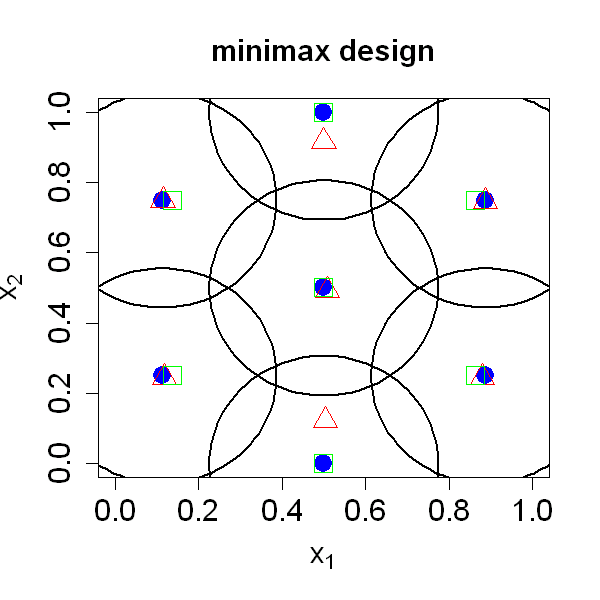

In [2]:
# 图 4.2

options(repr.plot.width=5,repr.plot.height=5)
p=2;n=7
DmM=matrix(c(.5,.5,.5,0,.5,1,1/3-1/12*sqrt(7),.25,1/3-1/12*sqrt(7),.75,2/3+1/12*sqrt(7),.25,2/3+1/12*sqrt(7),.75),nrow=7,ncol=2,byrow=TRUE)
1/6*(sqrt(7)-1)
plot(DmM[,1],DmM[,2],xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),pch=16,col="blue",cex=2,main="minimax design",cex.main=1.5,cex.lab=1.5,cex.axis=1.5)
library(plotrix)
for(i in 1:7) draw.circle(DmM[i,1],DmM[i,2],radius=1/6*(sqrt(7)-1),lwd=2)

set.seed(10)
library(minimaxdesign)
D1=minimax(N=n,p=2,q=10)
points(D1,pch=2,col="red",cex=2)
mMdist(D1)$dist

library(LatticeDesign)
D2=InterleavedMinimaxD(p,n)$Design
points(D2,pch=0,col="green",cex=2)
mMdist(D2)$dist

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$